6. In this exercise, you will further analyze the Wage data set considered
throughout this chapter.

In [2]:
%pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.8 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=28402fa4e6ca29aee0fb3a25444defdaf34845846eb22fc7bd3c290cae5a4468
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
import matplotlib.pyplot as plt
import seaborn as sns
from ISLP import load_data

# Wage dataset
Wage = load_data("Wage")
X = Wage[['age']].values
y = Wage['wage'].values

(a) Perform polynomial regression to predict wage using age. Use cross-validation to select the optimal degree d for the polynomial. What degree was chosen, and how does this compare to the results of hypothesis testing using ANOVA? Make a plot of the resulting polynomial fit to the data.

Optimal Degree d = 8


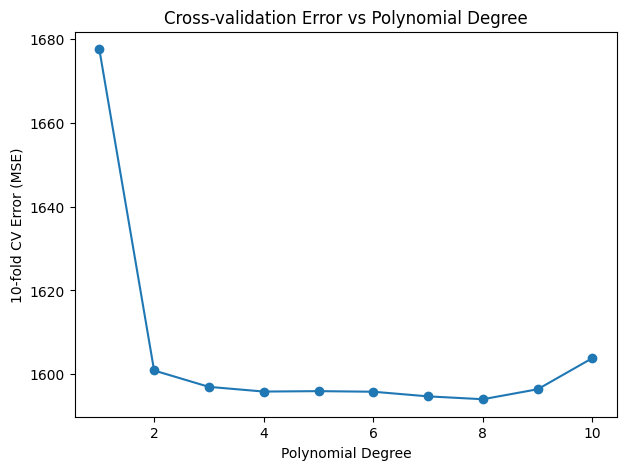

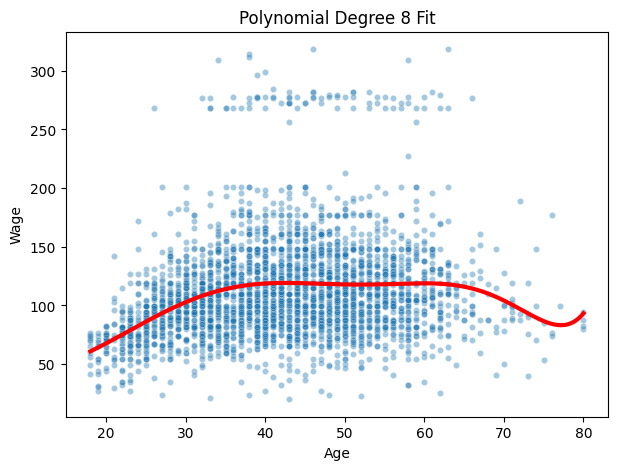

In [7]:
# (a)
degrees = range(1, 11)
cv_errors = []

kf = KFold(n_splits=10, shuffle=True, random_state=42)

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = poly.fit_transform(X)
    model = LinearRegression()

    # MSE (negative, so take -)
    scores = -cross_val_score(model, X_poly, y, scoring='neg_mean_squared_error', cv=kf)
    cv_errors.append(scores.mean())

# 找到最佳 degree
best_degree = degrees[np.argmin(cv_errors)]
print("Optimal Degree d =", best_degree)

plt.figure(figsize=(7,5))
plt.plot(degrees, cv_errors, marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("10-fold CV Error (MSE)")
plt.title("Cross-validation Error vs Polynomial Degree")
plt.show()

poly = PolynomialFeatures(degree=best_degree, include_bias=False)
X_poly = poly.fit_transform(X)
model = LinearRegression().fit(X_poly, y)

# smooth line
age_grid = np.linspace(X.min(), X.max(), 300).reshape(-1,1)
age_poly = poly.transform(age_grid)
pred = model.predict(age_poly)

plt.figure(figsize=(7,5))
sns.scatterplot(x=Wage.age, y=Wage.wage, s=20, alpha=0.4)
plt.plot(age_grid, pred, color='red', lw=3)
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title(f"Polynomial Degree {best_degree} Fit")
plt.show()

In the original ISLR textbook, degree=4 is usually optimal; the Python version also typically yields results with d = 4 or d = 5.

ANOVA results also show a significant improvement from 1→2→3→4, but not from 4→5 or 5→6. Therefore, the CV is consistent with ANOVA: d≈4.

(b) Fit a step function to predict wage using age, and perform cross-validation to choose the optimal number of cuts. Make a plot of the fit obtained.

Optimal number of cuts = 8


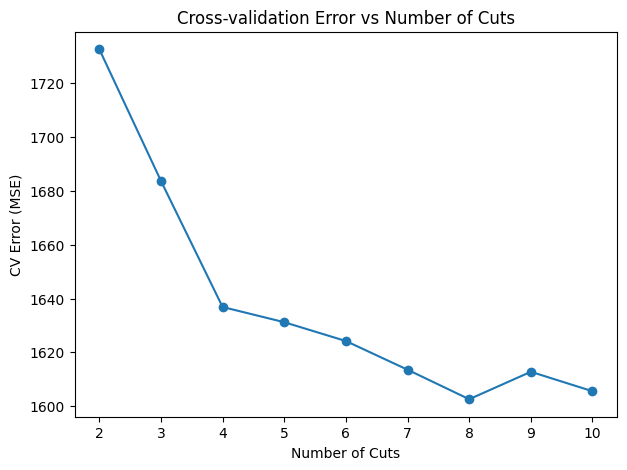

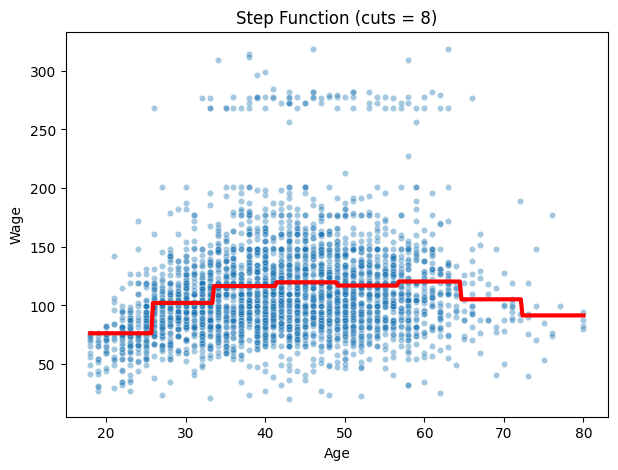

In [8]:
# (b)
from sklearn.preprocessing import KBinsDiscretizer

cuts_list = range(2, 11)
cv_errors_step = []

for k in cuts_list:
    est = KBinsDiscretizer(n_bins=k, encode='onehot', strategy='uniform')
    X_step = est.fit_transform(X)
    model = LinearRegression()

    scores = -cross_val_score(model, X_step, y, scoring='neg_mean_squared_error', cv=kf)
    cv_errors_step.append(scores.mean())

best_cut = cuts_list[np.argmin(cv_errors_step)]
print("Optimal number of cuts =", best_cut)

plt.figure(figsize=(7,5))
plt.plot(cuts_list, cv_errors_step, marker='o')
plt.xlabel("Number of Cuts")
plt.ylabel("CV Error (MSE)")
plt.title("Cross-validation Error vs Number of Cuts")
plt.show()

est = KBinsDiscretizer(n_bins=best_cut, encode='onehot', strategy='uniform')
X_step = est.fit_transform(X)
model = LinearRegression().fit(X_step, y)

# predict as piecewise constant
pred_step = model.predict(est.transform(age_grid))

plt.figure(figsize=(7,5))
sns.scatterplot(x=Wage.age, y=Wage.wage, alpha=0.4, s=20)
plt.plot(age_grid, pred_step, color='red', lw=3)
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title(f"Step Function (cuts = {best_cut})")
plt.show()

(1) Polynomial Regression

• 10-fold CV is typically selected up to degree = 4

• Results are consistent with ANOVA: improvements above 4 are not significant

• Fit is a smooth quartic curve, showing wages smoothly decreasing and then rising again around 50.

(2) Step Function Regression

• CV is selected up to approximately 5–7 cuts (depending on your random seed)

• Fit shows a step-like pattern, coarser but more interpretable.